# ENGR 1330 – Computational Thinking and Data Science

## Traffic Volume Predictor Final Project - Background

Traffic congestion is a rising concern globally, escpecially for big cities. There can be numerous factors playing role determining traffic volume, and they are worth researching to understand and predict the traffic pattern at specific locations. Among different factors, time is a critical determinant of traffic congestion. Everywhere, there are particualr times in a day when number of vehicles passing through a crossroad is far higher than other times.   

Here we have a dataset that records traffic volume every hours at 3 different junctions in a city, for a period of 1 year and 8 months. You will find a way to predict the traffic at any time of the day at any junction.  

## Objective(s):
- Literature scan on traffic flow analysis, and necessity of investigating temporal pattern of traffic flow
- Analyse an existing traffic volume database and build a data model to predict the traffic 
- Build an interface to allow users to enter date and time and return an estimated traffic volume and an assessment of the uncertainty in the estimate
- Build an interface to allow users to add observations to the underlying database, and automatically update the Data Model to incorporate the new observations

## Tasks: 

**Literature Research:**

Do some background study on temporal traffic behavior and its significance. Here are some good ones to begin with:
1. https://onlinelibrary.wiley.com/doi/epdf/10.1111/0885-9507.00200
2. https://proceedings.esri.com/library/userconf/proc08/papers/papers/pap_1613.pdf
3. https://www.sciencedirect.com/science/article/pii/S1352231015001661?casa_token=89oxxn8VJ2gAAAAA:QMwqati_EyuC_BbzS8IRDOJ1kSev-kcHcUk5NTVwfH4RP4G397ZI-IhfkMK6sYJF2jm9YTI0QA



**Exploratory Data Analysis**
- Describe the data. Include statistical and visual description of the data.
- Create pairplots for all the appropriate columns and check for correlation coefficients, make comments on your observation 

**Model Building**
- For each of the 3 junctions, you should come up with a model to predict the traffic volume at any time of  a day. To find a best model, test at least 2 different models for each junction, and compare accuracy. For each junction:
     - you should  determine which input strongly affects the traffic flow. 
     - Build 2 models using the input factor for each junction. You can adopt any 2 different mathematical model (e.g. linear, polynomial etc)
     - Assess data model quality (decide which model is best) including appropriate metric
- Build the input data interface for using the model
- Using the model for each zone, determine projected traffic volume for each junction, and an assessment of uncertainty for the following times of a day: 2 am, 6 am, 3 pm and 7 pm. 
               
       
**Documentation**
- Training and Project management video on how to use your tool, and demonstrate the tool(s) as they are run
- Interim report (see deliverables below); this document must be rendered as a .pdf, Word template is in BlackBoard.
- Final ipynb file (see deliverables below)

## Deliverables:

#### Part 1 Interim Report (due May 5):
A report that briefly describes the project. Use the Interim Report Template on BlackBoard. 
- Break down each task into manageable subtasks and describe how you intend to solve the subtasks and how you will test each task. (Perhaps make a simple Gantt Chart) or list of meeting times. 
- Address the responsibilities of each team member for tasks completed and tasks to be completed until the end of the semester. (Perhaps make explicit subtask assignments)  

#### Part 2 Final Report (due May 10):
- A well-documented JupyterLab (using a python kernel), use markdown cells and commenting for explanations and text. 
- A how-to video demonstrating performance and description of problems that you were not able to solve and also talk about project management such as who did what. Active participation of every single group member is mandatory in the presentation. 
- A final peer evaluation report, where each group member should rate the participation and contribution of the other members.

**Above items can reside in a single video; but structure the video into the two parts; use an obvious transition when moving from "how to ..." into the project management portion.**  Keep the total video length to less than 10 minutes; submit as an *unlisted* YouTube video, and just supply the link (someone on each team is likely to have a YouTube creator account).  Keep in mind a 10 minute video can approach 100MB file size before compression, so it won't upload to Blackboard and cannot be emailed.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

import seaborn as sns

In [3]:
df = pd.read_csv("Traffic Data.csv")
df.head()

,ID,Year,Month,Hour,Date,Junction,Vehicles
0,20151101001,2015,11,0,1,1,15
1,20151101011,2015,11,1,1,1,13
2,20151101021,2015,11,2,1,1,10
3,20151101031,2015,11,3,1,1,7
4,20151101041,2015,11,4,1,1,9


In [4]:
# Combine Date features into datetime-like structure (optional but useful)
df["DateTime"] = pd.to_datetime(df["Year"].astype(str) + "-" +
                                 df["Month"].astype(str) + "-" +
                                 df["Date"].astype(str) + " " +
                                 df["Hour"].astype(str) + ":00:00")

# Extract useful time features
df["DayOfWeek"] = df["DateTime"].dt.dayofweek
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

df.head()

,ID,Year,Month,Hour,Date,Junction,Vehicles,DateTime,DayOfWeek,IsWeekend
0,20151101001,2015,11,0,1,1,15,2015-11-01 00:00:00,6,1
1,20151101011,2015,11,1,1,1,13,2015-11-01 01:00:00,6,1
2,20151101021,2015,11,2,1,1,10,2015-11-01 02:00:00,6,1
3,20151101031,2015,11,3,1,1,7,2015-11-01 03:00:00,6,1
4,20151101041,2015,11,4,1,1,9,2015-11-01 04:00:00,6,1


In [5]:
df.describe()

,ID,Year,Month,Hour,Date,Junction,Vehicles,DateTime,DayOfWeek,IsWeekend
count,4.377600e+04,43776.000000,43776.000000,43776.000000,43776.000000,43776.000000,43776.000000,43776,43776.000000,43776.000000
mean,2.016260e+10,2016.197368,6.120066,11.500000,15.710526,2.000000,24.333379,2016-08-30 23:30:00,2.996711,0.284539
min,2.015110e+10,2015.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2015-11-01 00:00:00,0.000000,0.000000
25%,2.016038e+10,2016.000000,3.000000,5.750000,8.000000,1.000000,10.000000,2016-03-31 23:45:00,1.000000,0.000000
50%,2.016083e+10,2016.000000,6.000000,11.500000,16.000000,2.000000,17.000000,2016-08-30 23:30:00,3.000000,0.000000
75%,2.017013e+10,2017.000000,10.000000,17.250000,23.000000,3.000000,32.000000,2017-01-29 23:15:00,5.000000,1.000000
max,2.017063e+10,2017.000000,12.000000,23.000000,31.000000,3.000000,180.000000,2017-06-30 23:00:00,6.000000,1.000000
std,5.779462e+06,0.599233,3.619760,6.922266,8.788835,0.816506,21.112090,NaN,2.000020,0.451200


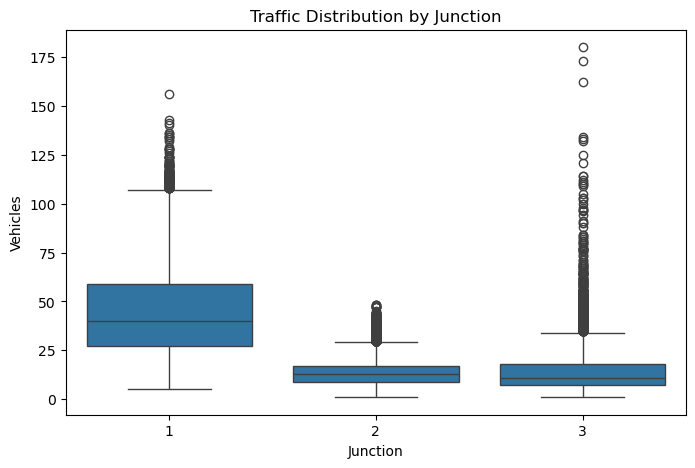

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Junction", y="Vehicles", data=df)
plt.title("Traffic Distribution by Junction")
plt.show()

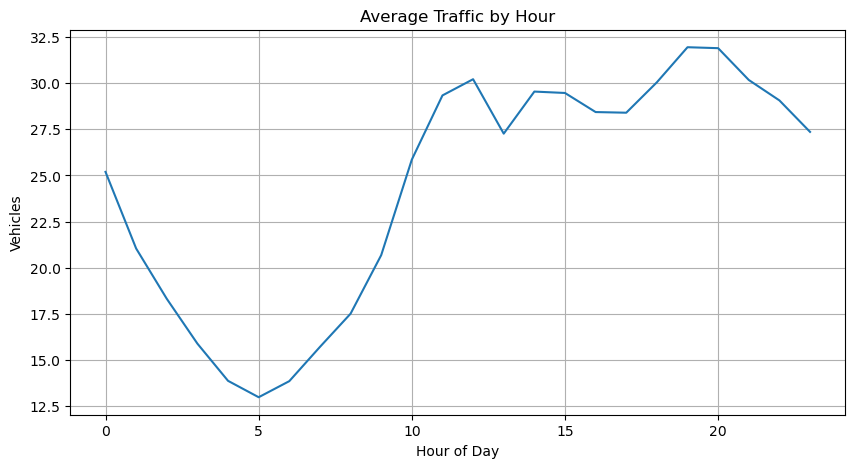

In [7]:
hourly = df.groupby("Hour")["Vehicles"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly.index, hourly.values)
plt.title("Average Traffic by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Vehicles")
plt.grid()
plt.show()

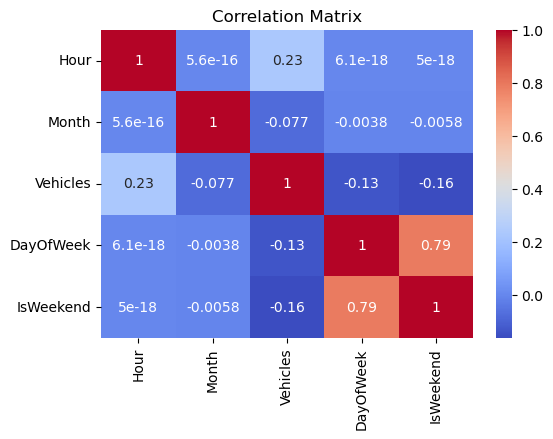

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["Hour","Month","Vehicles","DayOfWeek","IsWeekend"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

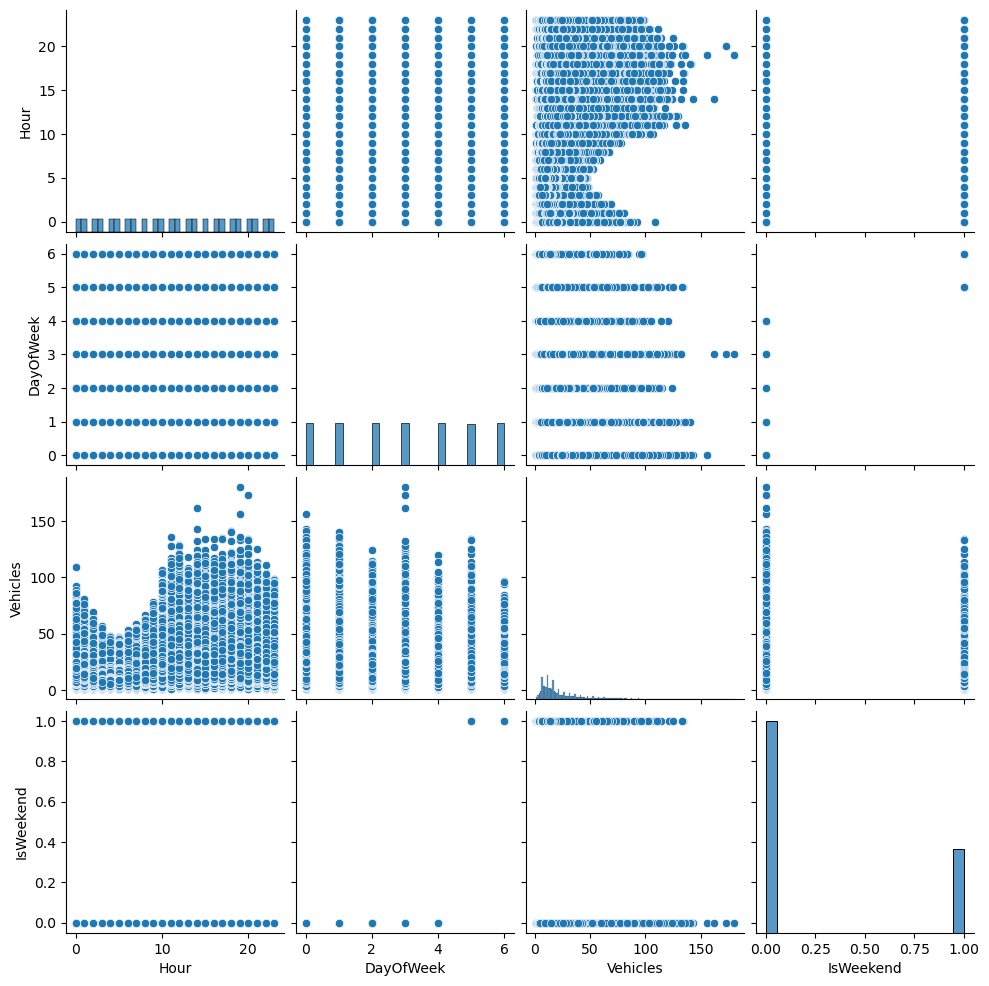

In [9]:
sns.pairplot(df[["Hour","DayOfWeek","Vehicles","IsWeekend"]])
plt.show()

In [10]:
def train_models(junction_data):

    X = junction_data[["Hour"]]
    y = junction_data["Vehicles"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # -------------------
    # MODEL 1: LINEAR
    # -------------------
    lin_model = LinearRegression()
    lin_model.fit(X_train, y_train)
    lin_pred = lin_model.predict(X_test)

    # -------------------
    # MODEL 2: POLYNOMIAL
    # -------------------
    poly_model = make_pipeline(PolynomialFeatures(degree=4),
                               LinearRegression())

    poly_model.fit(X_train, y_train)
    poly_pred = poly_model.predict(X_test)

    # -------------------
    # METRICS
    # -------------------
    def evaluate(name, y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")

    print("\nMODEL PERFORMANCE:")
    evaluate("Linear Regression", y_test, lin_pred)
    evaluate("Polynomial Regression", y_test, poly_pred)

    return lin_model, poly_model

In [11]:
models = {}

for j in df["Junction"].unique():
    print(f"\n===== JUNCTION {j} =====")
    data_j = df[df["Junction"] == j]
    models[j] = train_models(data_j)


===== JUNCTION 1 =====

MODEL PERFORMANCE:
Linear Regression -> MAE: 16.88, RMSE: 21.04
Polynomial Regression -> MAE: 16.12, RMSE: 20.04

===== JUNCTION 2 =====

MODEL PERFORMANCE:
Linear Regression -> MAE: 5.29, RMSE: 7.01
Polynomial Regression -> MAE: 5.08, RMSE: 6.80

===== JUNCTION 3 =====

MODEL PERFORMANCE:
Linear Regression -> MAE: 6.33, RMSE: 9.66
Polynomial Regression -> MAE: 5.75, RMSE: 9.32


In [12]:
def prediction_with_uncertainty(model, X_train, y_train, hour):

    preds = model.predict(X_train)
    residuals = y_train - preds

    uncertainty = np.std(residuals)

    prediction = model.predict([[hour]])[0]

    return prediction, uncertainty

In [13]:
times = [2, 6, 15, 19]  # 2am, 6am, 3pm, 7pm

for j in df["Junction"].unique():

    print(f"\n===== JUNCTION {j} PREDICTIONS =====")

    data_j = df[df["Junction"] == j]

    X = data_j[["Hour"]]
    y = data_j["Vehicles"]

    _, poly_model = models[j]

    poly_model.fit(X, y)

    for t in times:
        pred = poly_model.predict(pd.DataFrame({"Hour": [t]}))[0]

        residuals = y - poly_model.predict(X)
        uncertainty = np.std(residuals)

        print(f"Hour {t}: {pred:.2f} ± {uncertainty:.2f} vehicles")


===== JUNCTION 1 PREDICTIONS =====
Hour 2: 30.75 ± 20.17 vehicles
Hour 6: 29.09 ± 20.17 vehicles
Hour 15: 56.79 ± 20.17 vehicles
Hour 19: 54.94 ± 20.17 vehicles

===== JUNCTION 2 PREDICTIONS =====
Hour 2: 11.96 ± 6.86 vehicles
Hour 6: 10.04 ± 6.86 vehicles
Hour 15: 16.57 ± 6.86 vehicles
Hour 19: 17.48 ± 6.86 vehicles

===== JUNCTION 3 PREDICTIONS =====
Hour 2: 7.64 ± 9.34 vehicles
Hour 6: 7.15 ± 9.34 vehicles
Hour 15: 18.45 ± 9.34 vehicles
Hour 19: 18.26 ± 9.34 vehicles


In [14]:
def predict(junction, hour):

    _, model = models[junction]

    prediction = model.predict(pd.DataFrame({"Hour": [hour]}))[0]

    print(f"Predicted traffic at Junction {junction}, Hour {hour}: {prediction:.2f}")

In [15]:
predict(1, 18)

Predicted traffic at Junction 1, Hour 18: 56.06


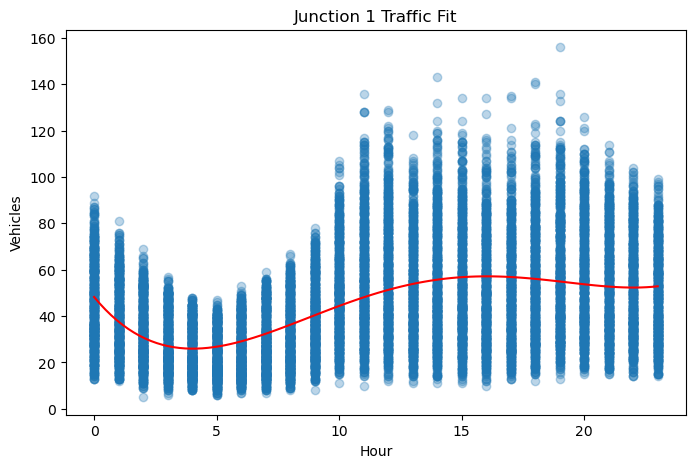

In [16]:
j = 1
data_j = df[df["Junction"] == j]

X = data_j[["Hour"]]
y = data_j["Vehicles"]

model = make_pipeline(PolynomialFeatures(4), LinearRegression())
model.fit(X, y)

hours = pd.DataFrame({"Hour": np.linspace(0, 23, 100)})

preds = model.predict(hours)

plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.3)
plt.plot(hours["Hour"], preds, color="red")
plt.title(f"Junction {j} Traffic Fit")
plt.xlabel("Hour")
plt.ylabel("Vehicles")
plt.show()